# Probabilistic Model Using VED

Volumetric Energy Density (VED) is the amount of energy (capacity, kWh) that can be stored in a given volume or how much laser energy is applied per unit volume of material.

**VED = P/vth**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

This model predicts a **distribution** of fatigue lives instead of one value.

Here, VED is a **process input** that controls defect statistics.

# Imports

In [126]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import lognorm, weibull_min, genextreme, kstest
from dataclasses import dataclass
import random

# 1. Input Parameters
collects all fixed inputs (material, geometry, loading, AM process)

## 1.1. Material Parameters
Paris law constants, fracture toughness, threshold SIF

Paris–Erdogan law:  **da/dN = C · ΔK^m**
- valid for  K_th < ΔK < K_c  (Stage II crack growth)

In [127]:
C = 1.0e-11     # Paris constant [m/cycle / (MPa√m)^m]  — Ti-6Al-4V LPBF (literature)
m = 3.2         # Paris exponent    [–]

K_c = 60.0      # fracture toughness [MPa√m]
K_th = 3.0      # threshold SIF range [MPa√m]
E = 114.0       # Young's modulus [GPa]

print(f"Paris law: da/dN = {C:.2e} * deltaK^{m}")
print(f"K_c = {K_c} MPa√m, K_th = {K_th} MPa√m, E = {E} GPa")

Paris law: da/dN = 1.00e-11 * deltaK^3.2
K_c = 60.0 MPa√m, K_th = 3.0 MPa√m, E = 114.0 GPa


**CITE SOURCES FOR VARIABLE VALUES**

## 1.2. Geometry Parameters
specimen dimensions, defect location (→ Y factor)

In [128]:
w = 5e-3        # cross-section width [m]
h_s = 5e-3      # cross-section height [m]
L = 20e-3       # gauge length [m]

V_gauge = w * h_s * L          # gauge volume [m^3]
V_gauge_mm3 = V_gauge * 1e9    # [mm^3] for display

# Geometry correction factor Y (Murakami framework)
#   Y = 0.5 for internal defect
#   Y = 0.6 for surface defect
defect_location = "internal"
Y = 0.5 if defect_location == "internal" else 0.6

print(f"Gauge volume V = {V_gauge_mm3:.1f} mm^3")
print(f"Defect location: {defect_location} → Y = {Y}")

Gauge volume V = 500.0 mm^3
Defect location: internal → Y = 0.5


## 1.3. Loading Parameters
stress amplitude, mean stress, frequency

In [129]:
sigma_a = 200.0     # stress amplitude [MPa]
sigma_m = 0.0       # mean stress [MPa]  (0 → fully reversed, R = -1)
freq = 20.0         # cyclic frequency [Hz]

sigma_max = sigma_m + sigma_a
sigma_min = sigma_m - sigma_a
R = sigma_min / sigma_max if sigma_max != 0 else float("nan")

# Effective stress range:
    # crack faces close under compression, no damage contribution
delta_sigma = sigma_max - max(sigma_min, 0.0)   # deltaK = Y*delta_sigma*√(pi*a)

print(f"sigma_a = {sigma_a} MPa, sigma_m = {sigma_m} MPa")
print(f"sigma_max = {sigma_max:.1f}, sigma_min = {sigma_min:.1f}, R = {R:.2f}")
print(f"Effective delta_sigma = {delta_sigma:.1f} MPa")

sigma_a = 200.0 MPa, sigma_m = 0.0 MPa
sigma_max = 200.0, sigma_min = -200.0, R = -1.00
Effective delta_sigma = 200.0 MPa


**CITE SOURCES FOR VARIABLE VALUES**

## 1.4. Process Params & VED
laser power, scan speed, hatch spacing, layer thickness

Volumetric Energy Density (VED) is the amount of energy (capacity, kWh) that can be stored in a given volume or how much laser energy is applied per unit volume of material.

**VED = P / (vht)**

where
- power, P, [W] = [J/s]
- scan velocity, v, [mm/s]
- layer thickness, t, [mm]
- hatch spacing, h, [mm]

and
- low VED → lack-of-fusion porosity
- high VED → keyhole porosity
- both increase defect density

Here, VED is a **process input** that controls defect statistics.

In [130]:
# define process parameters
P = 200.0     # laser power [W]
v = 1200.0    # scan speed [mm/s]
h = 0.11      # hatch spacing [mm]
t = 0.03      # layer thickness [mm]

# volumetric energy density
VED = P / (v * h * t)

print(f"P = {P} W,  v = {v} mm/s,  h = {h} mm,  t = {t} mm")
print(f"VED = {VED:.2f} J/mm^3")

P = 200.0 W,  v = 1200.0 mm/s,  h = 0.11 mm,  t = 0.03 mm
VED = 50.51 J/mm^3


**CITE SOURCES FOR VARIABLE VALUES**

# 2. Volume, Defect Density, and PDF
- Volumetric Energy Density (VED) from AM process parameters
- Defect number density rho_def from XCT data
- Expected defect count in the gauge volume
- Parametric PDF fit to measured defect sizes

## 2.1. Defect Density
The defect density [no. of defects/mm^3] is given by

**rho_def = N_def / V_scan**

Expected defects in gauge volume:  **⟨N⟩ = rho_def · V**

In [131]:
#V_gauge_mm3 = 1.0    # inspected specimen volume [mm^3]
VED_opt = 80        # optimal VED
rho_min = 50        # min defect density at optimal VED [defects/mm^3]
rho_max = 100       # max defect density at optimal VED [defects/mm^3]
alpha = 0.08        # sensitivity of defect density to VED deviations
std_dev = 10        # std dev (width parameter) of Gaussian curve

# define function for defect density model
def defect_density(VED):
    # U-shaped defect density curve
    # empirical quadratic model, Taylor expansion
    #rho = rho_min + alpha * (VED - VED_opt)**2
    #rho = rho_max - alpha * (VED - VED_opt)**2
    rho = rho_max * np.exp(-(VED-VED_opt)**2 / (2 * std_dev**2))

    return rho

## 2.2. VED–Defect Density Correlation
A U-shaped empirical curve relates VED to defect density:
both under- and over-melting increase porosity.

In [132]:
# defect density for this VED
rho_defects = defect_density(VED)

# expected number of defects
lambda_defects = rho_defects * V_gauge_mm3

print("Defect density =", rho_defects, "defects/mm^3")
print("Expected number of defects =", lambda_defects, "defects")

Defect density = 1.290990763670983 defects/mm^3
Expected number of defects = 645.4953818354916 defects


In [133]:
VED_sweep = [20, 40, 60, 80, 100, 120, 140, 160, 180, 200]  # VED range for sweep [J/mm^3]

rho_sweep = []       # list to store density values for each VED

for VED_i in VED_sweep:
    rho = defect_density(VED_i)
    rho_sweep.append(rho)

# np.linspace(20, 40, 60, 80, 100, 120, 140, 160, 180, 200)   
# rho_sweep = defect_density(VED_sweep)   # corresponding defect densities
rho_op = defect_density(VED)              # defect density at operating VED

**NOTE: **rho_op** and **rho_defects** are the same!!

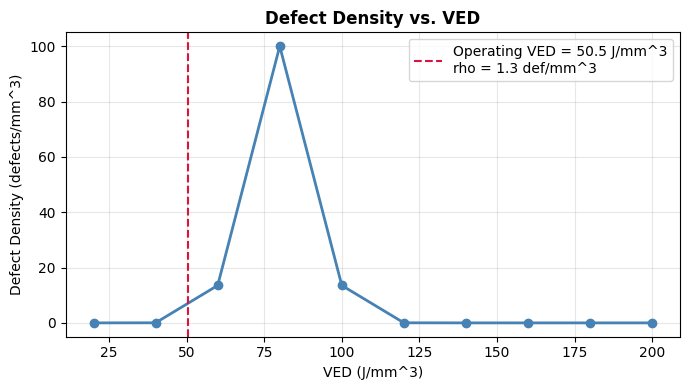

In [134]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(VED_sweep, rho_sweep, marker='o', color="steelblue", linewidth=2)

# add line indicating operating defect density
ax.axvline(VED, color="crimson", 
           linestyle="--", linewidth=1.5,
           label=f"Operating VED = {VED:.1f} J/mm^3\nrho = {rho_op:.1f} def/mm^3")

# axes labels, title, legend, grid
ax.set_title("Defect Density vs. VED", fontweight="bold")
ax.set_xlabel("VED (J/mm^3)")
ax.set_ylabel("Defect Density (defects/mm^3)")

# legend, grid
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("graphs/2_VED_rho.png", dpi=150)
plt.show()

## 2.3. Synthetic Defect Population
Generate a synthetic defect population (many specimens, each with many defects) from the VED.

### 2.3.a. Defect Size Distribution Parameters
Connect LPBF process parameters (VED) to defect-size population with **empirical statistical models**.

Assume defect size follows a **lognormal distribution**.

**values are placeholder values!!**

In [135]:
# define functions to calculate defect size distribution parameters from VED

# mean of ln(defect size)
def defect_mu(VED, VED_opt):
    mu_0 = np.log(50e-6)        # assume exp(mu_ln) = 50 micrometers at VED_opt
    beta = 2e-6                 # sensitivity to VED deviation  [ln(m) / (J/mm^3)^2]
    
    mu_ln = mu_0 + beta * (VED - VED_opt)**2
    return mu_ln

# std dev of ln(defect size) as a function of VED
def defect_sigma(VED, VED_opt):
    sigma_0 = 0.35              # minimum log-scatter at optimal VED
    gamma = 1e-5                # scatter sensitivity to VED deviation

    sigma_ln = sigma_0 + gamma * (VED - VED_opt)**2
    return sigma_ln

mu_ln = defect_mu(VED, VED_opt)         # mean of log, ~3-6
sigma_ln = defect_sigma(VED, VED_opt)   # std dev of log, ~0.2-1

print(f"Defect size lognormal parameters at VED = {VED:.1f} J/mm^3:")
print(f"  mu_ln = {mu_ln:.4f} → median defect = {np.exp(mu_ln)*1e6:.1f} micrometers")
print(f"  sigma_ln = {sigma_ln:.4f}")

Defect size lognormal parameters at VED = 50.5 J/mm^3:
  mu_ln = -9.9017 → median defect = 50.1 micrometers
  sigma_ln = 0.3587


### 2.3.b. Generate Synthetic Population

In [136]:
rng = np.random.default_rng(seed=42)

# # define function to generate sizes of defects inside each specimen 
# # based on a lognormal distribution
def generate_defects(n_defects, mu, sigma):
    return rng.lognormal(mu,           # mean of logarithm 
                         sigma,        # std dev
                         n_defects)    # no. of random samples generated

In [137]:
# generate a random number of varying defects
# combine n_local and specimen_defects
n_specimens = random.randint(2, 1000)

all_specimens = []              # empty list to store info on all specimens

for i in range(n_specimens):

    # random number of defects
    n_local = rng.poisson(lambda_defects)
    n_local = max(n_local, 1)

    # random defect sizes
    defects = generate_defects(n_local, mu_ln, sigma_ln)

    all_specimens.append(defects)

## 2.4. Fit Parametric PDF
Three candidate distributions are fitted by MLE.

The best distribution is selected by the lowest Kolmogorov–Smirnov statistic.

In [138]:
# convert a list of sequences into a single array
all_specs_array = np.concatenate(all_specimens).astype(float)

In [139]:
# define a function to fit a parametric distribution to the defect sizes by MLE
def fit_distribution(sizes, dist_name):
    # lognormal distribution
    if dist_name == "lognormal":
        s, loc, scale = lognorm.fit(sizes, floc=0)
        frozen = lognorm(s=s, loc=0, scale=scale)
        params = {"mu_ln": np.log(scale), "sigma_ln": s}

    # Weibull distribution (3-parameter, with loc fixed at 0)
    elif dist_name == "Weibull":
        k, loc, scale = weibull_min.fit(sizes, floc=0)
        frozen = weibull_min(c=k, loc=0, scale=scale)
        params = {"k": k, "lambda": scale}

    # Gumbel distribution (for maxima, with loc and scale)
    elif dist_name == "Gumbel":
        from scipy.stats import gumbel_r
        loc, scale = gumbel_r.fit(sizes)
        frozen = gumbel_r(loc=loc, scale=scale)
        params = {"loc": loc, "scale": scale}

    else:
        raise ValueError(f"Unknown distribution: {dist_name!r}")

    ks_stat, ks_p = kstest(sizes, frozen.cdf)
    return frozen, ks_stat, ks_p, params

# fit each candidate distribution
candidates = ["lognormal", "Weibull", "Gumbel"]
fit_results = {}

In [140]:
# print results in a table to compare goodness-of-fit
print(f"{'Distribution':<12}  {'KS statistic':>14}  {'p-value':>10}")
print("-" * 42)

for name in candidates:
    frozen, ks, p, params = fit_distribution(all_specs_array, name)
    fit_results[name] = (frozen, ks, p, params)
    print(f"{name:<12}  {ks:>14.4f}  {p:>10.4f}")

best_name = min(fit_results, key=lambda n: fit_results[n][1])
best_frozen, best_ks, best_p, best_params = fit_results[best_name]
print(f"\nBest fit: {best_name} (KS = {best_ks:.4f}, p = {best_p:.4f})")

param_str = ", ".join(f"{k} = {v:.4g}" for k, v in best_params.items())
print(f"Parameters: {param_str}")

Distribution    KS statistic     p-value
------------------------------------------
lognormal             0.0018      0.4216
Weibull               0.0616      0.0000
Gumbel                0.0050      0.0000

Best fit: lognormal (KS = 0.0018, p = 0.4216)
Parameters: mu_ln = -9.902, sigma_ln = 0.3592


### 2.4.a. Defect Size Histogram & PDF

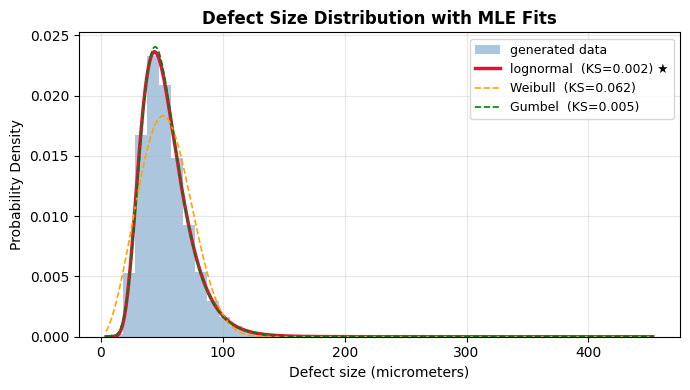

In [141]:
# plot histogram of defect sizes and overlay fitted PDFs
fig, ax = plt.subplots(figsize=(7, 4))

sizes_um = all_specs_array * 1e6   # convert to micrometers for readability
ax.hist(sizes_um, bins=30, density=True, alpha=0.45,
        color="steelblue", label="generated data")

# overlay all three fitted PDFs
colors = {"lognormal": "crimson", "Weibull": "orange", "Gumbel": "green"}
x_m = np.linspace(all_specs_array.min() * 0.5, all_specs_array.max() * 1.5, 500)
x_um = x_m * 1e6

for name, (frozen, ks, p, _) in fit_results.items():
    pdf_vals = frozen.pdf(x_m) / 1e6   # Jacobian: dx_m = dx_um / 1e6
    lw = 2.5 if name == best_name else 1.2
    ls = "-" if name == best_name else "--"
    ax.plot(x_um, pdf_vals, color=colors[name], linewidth=lw, linestyle=ls,
            label=f"{name}  (KS={ks:.3f})" + (" ★" if name == best_name else ""))

# axes labels, title
ax.set_title("Defect Size Distribution with MLE Fits", fontweight="bold")
ax.set_xlabel("Defect size (micrometers)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_defect_pdf.png", dpi=150)
plt.show()

## 2.5. Max.-Defect Distribution
Each specimen contains many defects.

Fatigue failure is controlled by the **largest** defect (Murakami).

Instead of taking all the defects from every specimen, only the critical (max.) defect will be chosen for further analysis.

The distribution of per-specimen maxima follows a Generalized Extreme Value (GEV) distribution.

In [142]:
# define function to select the crtical (max.) defect
def critical_defect(defects):
    return np.max(defects)

max_defects = []        # empty list to store every max. defect
sqrt_A = []             # empty list to store every sqrt_A

max_defects = np.array([
    np.max(defects)
    for defects in all_specimens
])

sqrt_A = np.array([max_defects])

### 2.5.a. Generalized Extreme Value Distribution (GEV)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

In [143]:
# convert arrays for plotting
sqrt_A = np.asarray(sqrt_A, dtype=float)
sqrt_A = sqrt_A[np.isfinite(sqrt_A)]

print(len(sqrt_A))
print(np.min(sqrt_A))
print(np.max(sqrt_A))
print(np.std(sqrt_A))


370
0.00011926986378352892
0.0003018275373939053
2.631614397392101e-05


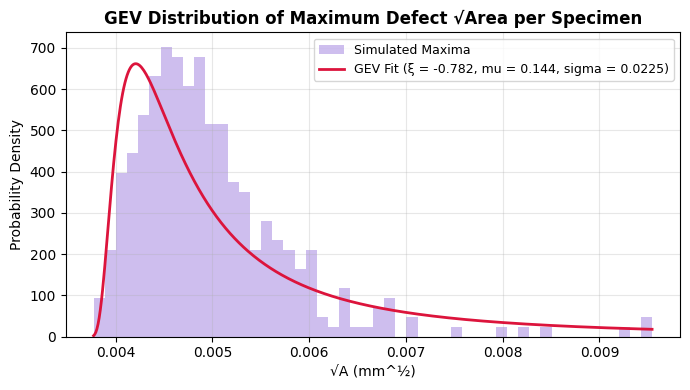

In [144]:
# GEV fit to per-specimen maximum defect sizes
        # gev_c = shape parameter (ξ)
        # gev_loc = location parameter (mu)
        # gev_scale = scale parameter (sigma)
gev_c, gev_loc, gev_scale = genextreme.fit(sqrt_A)

x_gev = np.linspace(sqrt_A.min(), sqrt_A.max(), 500)
pdf_gev = genextreme.pdf(x_gev, gev_c, gev_loc, gev_scale)

# convert [sqrt(m)] to [sqrt(mm)]
conv = np.sqrt(1000)

fig, ax = plt.subplots(figsize=(7, 4))

ax.hist(sqrt_A * conv,
        bins=50,
        density=True,
        alpha=0.45,
        color="mediumpurple",
        label="Simulated Maxima")

ax.plot(x_gev * conv,
        pdf_gev / conv,
        color="crimson",
        linewidth=2,
        label=f"GEV Fit (ξ = {gev_c:.3f}, mu = {gev_loc*1e3:.3f}, sigma = {gev_scale*1e3:.4f})")

# axes labels, title
ax.set_title("GEV Distribution of Maximum Defect √Area per Specimen", fontweight="bold")
ax.set_xlabel("√A (mm^½)")
ax.set_ylabel("Probability Density")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_GEV.png", dpi=150)
plt.show()

## 2.6. Paris-Law Fatigue Life Formulae
Integrating Paris law from a_0 to a_f with the Shiozawa approximation
(a_f >> a_i, so the a_f term → 0 for m > 2):

        N_f ≈ 2 / [(m-2) · C · (Y·delta_sigma)^m · pi^(m/2)] · a_i^(1 - m/2)

Re-written in terms of the initial SIF range deltaK_i = Y·delta_sigma·√(pi·a_i):

        N_f ≈ 2 / [(m-2) · C · pi · (Y·delta_sigma)^2] · deltaK_i^(2-m)

In [145]:
# define function to find the fatigue life, N, based on the given parameters

# based on Basquin's law
def fatigue_life_basquin(stress_amp, defect_size, C, m, n):
    return C / ((stress_amp**m) * (defect_size**n))

# based on Paris law
def fatigue_life_paris(a_i, sigma_a, C, m, Y, delta_sigma=None):

    # fully reversed (R = -1)
    if delta_sigma is None:
        delta_sigma = 2.0 * sigma_a
    
    # constant of Paris/Shiozawa equation
    coeff = 2.0 / ((m - 2) * C * (Y * delta_sigma)**m * np.pi**(m / 2))

    Nf = coeff * a_i**(1.0 - m / 2.0)
    return Nf

The **stress intensity factor, delta(K)**, the measure of the severity of a crack situation, is determined by

**delta(K) = Y * stress_amp * sqrt(pi * A)**

Assume the defect_size is the crack length: defect_size, A = crack_length, a

In [146]:
# define function to compute stress intensity factor, delta(K)
def stress_intensity_factor(stress_amp, defect_size):
    return Y * stress_amp * np.sqrt(np.pi * defect_size)

# define a function to compute the initial SIF range deltaK_i for a given initial crack size a_i
def delta_K_initial(a_i, delta_sigma, Y):
    deltaK_i = Y * delta_sigma * np.sqrt(np.pi * a_i)   # [MPa√m]
    return deltaK_i

## 2.7. Fatigue Life Dist. at Fixed Stress
Paris law & Shiozawa give N_f for each specimen.

The resulting distribution captures the scatter from defect variability alone.

In [147]:
S_fixed = sigma_a   # stress amplitude [MPa]

# empty lists to store info
Nf_samples = []
dKi_samples = []
Nnorm_samples = []

# compute fatigue life, deltaK_i, and Murakami √area for each specimen
for a0 in max_defects:
    Nf = fatigue_life_paris(a0, S_fixed, C, m, Y)
    dKi = delta_K_initial(a0, delta_sigma, Y)
    Nnorm = Nf / np.sqrt(a0)        # normalized life, N/√A

    Nf_samples.append(Nf)
    dKi_samples.append(dKi)
    Nnorm_samples.append(Nnorm)

### 2.7.a Shiozawa Plot: deltaK_i vs N_f / √A
Expected slope from Paris law:

deltaK_i ∝ (N/√A)^(1/(2-m)) → **slope = 1/(2-m)**

In [148]:
# clean Nf_samples
Nf_samples = np.asarray(Nf_samples, dtype=float)

# keep only valid positive finite fatigue lives
Nf_samples = Nf_samples[np.isfinite(Nf_samples) & (Nf_samples > 0)]

In [149]:
# log-log linear fit
log_Nnorm = np.log10(Nnorm_samples).flatten()
log_dKi = np.log10(dKi_samples).flatten()

In [150]:
# fit line
slope, intercept = np.polyfit(log_Nnorm, log_dKi, 1)
a_fit = 10**intercept

# compare slope to expected from Paris law
expected_slope = 1.0 / (2.0 - m)
print(f"Shiozawa log-log fit: slope = {slope:.4f}")
print(f"Expected from Paris (m={m}): slope = {expected_slope:.4f}")

# convert to numpy arrays
Nnorm_samples = np.asarray(Nnorm_samples, dtype=float)

N_norm_line = np.logspace(
    np.log10(Nnorm_samples.min()),
    np.log10(Nnorm_samples.max()),
    300
)
dK_line = a_fit * N_norm_line**slope

Shiozawa log-log fit: slope = -0.4545
Expected from Paris (m=3.2): slope = -0.8333


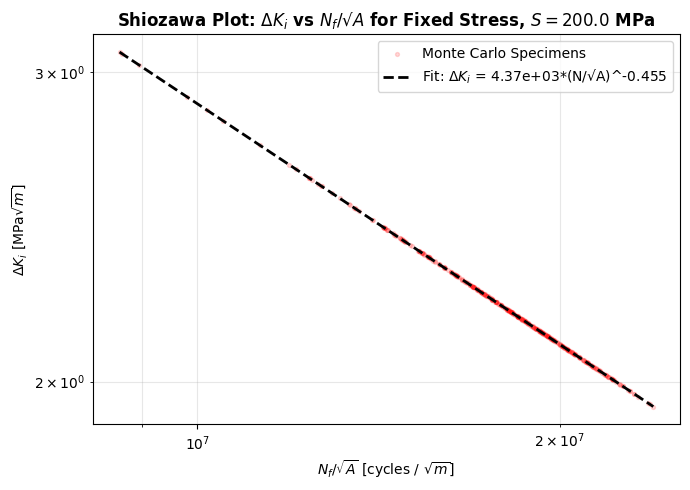

In [151]:
# plot Shiozawa plot
fig, ax = plt.subplots(figsize=(7, 5))
# show Monte Carlo specimens as scatter points
ax.scatter(Nnorm_samples, dKi_samples, alpha=0.15, s=8, color="red",
           label="Monte Carlo Specimens")

# show fitted line from log-log fit
ax.plot(N_norm_line, dK_line, color="black", linewidth=2, linestyle="--",
        label=f"Fit: $\\Delta K_i$ = {a_fit:.2e}*(N/√A)^{slope:.3f}")

# log-log scale for Shiozawa plot
ax.set_xscale("log")
ax.set_yscale("log")

# axes labels, title
ax.set_title(f"Shiozawa Plot: $\\Delta K_i$ vs $N_f / √A$ for Fixed Stress, $S = {S_fixed}$ MPa",
             fontweight="bold")
ax.set_xlabel("$N_f / \\sqrt{A}$ [cycles / $\\sqrt{m}$]")
ax.set_ylabel("$\\Delta K_i$ [MPa$\\sqrt{m}$]")

# legend, grid
ax.legend()
ax.grid(alpha=0.3, which="both")

# save and show
plt.tight_layout()
plt.savefig("graphs/2_shiozawa.png", dpi=150)
plt.show()

### 2.7.b Reliability Curves: Empirical & Weibull Model

The fraction of specimens surviving beyond N cycles:

**R(N) = P(N_f > N)**

The Weibull model **R(N) = exp[-(N/η)^β]** is fitted for comparison

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

Weibull: β = 14.473, η = 2.319e+05
  B10 (10% failure) = 1.985e+05 cycles
  B50 (50% failure) = 2.261e+05 cycles


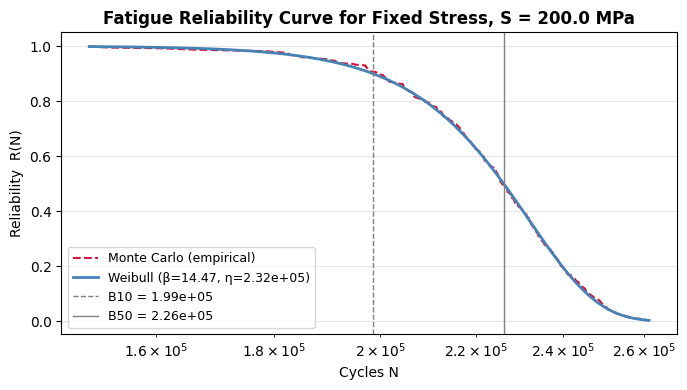

In [152]:
lives_sorted = np.sort(Nf_samples)
R_empirical  = 1.0 - np.arange(len(lives_sorted)) / len(lives_sorted)

# Weibull MLE fit
shape_w, _, scale_w = weibull_min.fit(Nf_samples, floc=0)
N_vals = np.linspace(lives_sorted.min(), lives_sorted.max(), 500)
R_weibull = np.exp(-(N_vals / scale_w)**shape_w)

# B10 and B50 lives
B10 = scale_w * (-np.log(0.90))**(1.0 / shape_w)        # 10% failure → R = 0.90
B50 = scale_w * (-np.log(0.50))**(1.0 / shape_w)        # 50% failure → R = 0.50
print(f"Weibull: β = {shape_w:.3f}, η = {scale_w:.3e}")
print(f"  B10 (10% failure) = {B10:.3e} cycles")
print(f"  B50 (50% failure) = {B50:.3e} cycles")

# plot reliability curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(lives_sorted, R_empirical, color="crimson", linewidth=1.5,
        linestyle="--", label="Monte Carlo (empirical)")
ax.plot(N_vals, R_weibull, color="steelblue", linewidth=2,
        label=f"Weibull (β={shape_w:.2f}, η={scale_w:.2e})")
# show B10 and B50 as vertical lines
ax.axvline(B10, color="grey", linewidth=1, linestyle="--",
           label=f"B10 = {B10:.2e}")
ax.axvline(B50, color="grey", linewidth=1,
           label=f"B50 = {B50:.2e}")

# log scale for reliability plot
ax.set_xscale("log")

# axes labels, title
ax.set_title(f"Fatigue Reliability Curve for Fixed Stress, S = {S_fixed} MPa",
             fontweight="bold")
ax.set_xlabel("Cycles N")
ax.set_ylabel("Reliability  R(N)")

# legend, grid
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# save and show
plt.tight_layout()
plt.savefig("graphs/2_reliability.png", dpi=150)
plt.show()

## 2.8. Shiozawa Curves for Varying Stress Amps.

Each stress level produces a shifted band on the **deltaK_i vs N_f/√A** plot.

With Paris law physics, these bands should **collapse onto a single trendline** when the Murakami normalization is applied, thus confirming the consistency of the framework.

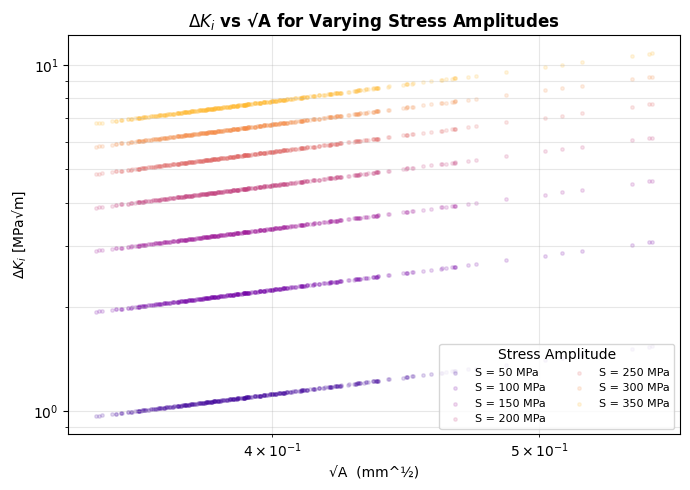

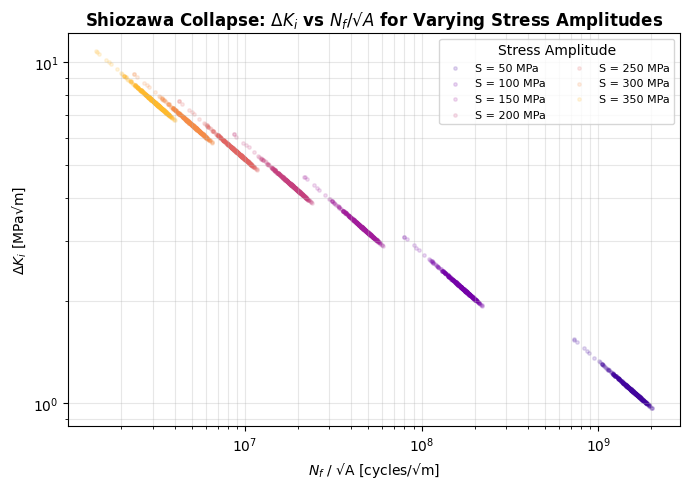

In [154]:
S_vals = [50, 100, 150, 200, 250, 300, 350]     # stress amplitudes to sweep [MPa]

# create subplots for deltaK_i vs √A and deltaK_i vs N/√A
fig1, ax1 = plt.subplots(figsize=(7, 5))    # deltaK_i vs √A
fig2, ax2 = plt.subplots(figsize=(7, 5))    # deltaK_i vs N/√A  (Shiozawa collapse)

colors_s = plt.cm.plasma(np.linspace(0.1, 0.85, len(S_vals)))

for Si, ci in zip(S_vals, colors_s):
    ds_i   = 2.0 * Si                       # delta_sigma for R = -1
    Nf_i   = fatigue_life_paris(max_defects, Si, C, m, Y, delta_sigma=ds_i)
    dKi_i  = delta_K_initial(max_defects, ds_i, Y)
    sqA_i  = np.sqrt(max_defects)
    Nnorm_i   = Nf_i / sqA_i

    ax1.scatter(sqA_i * conv, dKi_i, alpha=0.15, s=6, color=ci,
                label=f"S = {Si} MPa")
    ax2.scatter(Nnorm_i, dKi_i, alpha=0.15, s=6, color=ci,
                label=f"S = {Si} MPa")

for ax, xlabel, title in [
    # x-axis label, title for each plot
    (ax1, "√A  (mm^½)",
     "$\\Delta K_i$ vs √A for Varying Stress Amplitudes"),
    (ax2, "$N_f$ / √A [cycles/√m]",
     "Shiozawa Collapse: $\\Delta K_i$ vs $N_f / √A$ for Varying Stress Amplitudes"),
]:
    # log-log scale for both plots
    ax.set_xscale("log")
    ax.set_yscale("log")

    # axes labels, titles for both plots
    ax.set_xlabel(xlabel)
    ax.set_ylabel("$\\Delta K_i$ [MPa√m]")
    ax.set_title(title, fontweight="bold")
    
    # legends, grids
    ax.legend(fontsize=8, ncol=2, title="Stress Amplitude")
    ax.grid(alpha=0.3, which="both")

# save and show
fig1.tight_layout(); fig1.savefig("graphs/2_shiozawa_dK_sqrtA.png", dpi=150)
fig2.tight_layout(); fig2.savefig("graphs/2_shiozawa_collapse.png",  dpi=150)
plt.show()

# Monte Carlo Loop

## Fixed Stress

In [155]:
# set fixed stress amplitude, S, [MPa]
S_fixed = 250

# list to store results
lives = []          # list to store fatigue lives
M = []              # list to store Murakami parameter
max_defects = []    # list to store max defects
K = []              # list to store stress intensity factors
N_norm = []         # list to store normalized fatigue lives

for i in range(1000):
    # random no. of defects for this specimen
    n_local = calculate_Nd(rho_defects, V_gauge_mm33)

    # avoid empty specimen
    n_local = max(n_local, 1)                       

    defects = generate_defects(n_local, mu, sigma)

    A_crit = critical_defect(defects)
    N = fatigue_life(S_fixed, A_crit, C, m, n)
    Murakami = np.sqrt(A_crit)                      # Murakami parameter for defect size, sqrt(A)
    delta_K = stress_intensity_factor(S_fixed, A_crit)
    N_normal = N / Murakami                         # normalized fatigue life, N / sqrt(A)     

    # store results
    lives.append(N)
    M.append(Murakami)
    max_defects.append(A_crit)
    K.append(delta_K)
    N_norm.append(N_normal)

NameError: name 'calculate_Nd' is not defined

### Fatigue Life

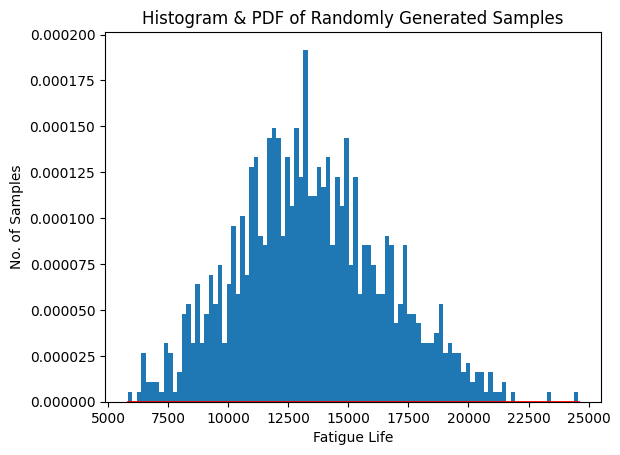

In [ ]:
# plot fatigue life histogram
count, bins, ignored = plt.hist(lives,
                                bins=100,
                                density=True,
                                align='mid')

x1 = np.linspace(min(bins), max(bins), n_defects)
pdf1 = (np.exp(-(np.log(x1)-mu)**2/(2*sigma**2))
       /(x1*sigma*np.sqrt(2*np.pi)))

# axis labels
plt.title('Histogram & PDF of Randomly Generated Samples')
plt.xlabel('Fatigue Life')
plt.ylabel('No. of Samples')

plt.plot(x1, pdf1, linewidth=2, color='r')
plt.axis('tight')
plt.show()

In [ ]:
# mean fatigue life
N_avg = np.mean(lives)

# std dev of faigue life
N_sigma = np.std(lives)

print("The average fatigue life is", N_avg)
print("The standard deviation of the fatigue life is", N_sigma)

The average fatigue life is 13462.920366679791
The standard deviation of the fatigue life is 3092.9994155299673


### GEV, P vs sqrt(A)
- each specimen contains many defects
- fatigue failure is governed by the largest critical defect
- so the distribution of maxima tends toward a GEV distribution

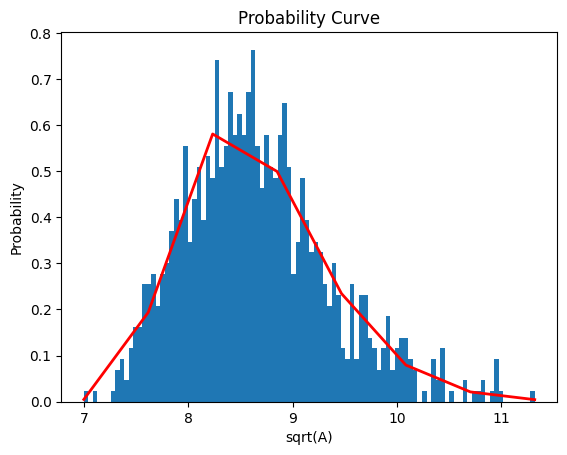

In [ ]:
# failure probability, P vs sqrt(defect_size)
c, loc, scale = genextreme.fit(M)

# show histogram and probability density function
count, bins, ignored = plt.hist(M,
                                bins=100,
                                density=True,
                                align='mid')

# calculate pdf
x3 = np.linspace(min(M), max(M), n_defects)
pdf3 = genextreme.pdf(x3, c, loc, scale)

# axis labels
plt.title('Probability Curve')
plt.xlabel('sqrt(A)')
plt.ylabel('Probability')

plt.plot(x3, pdf3, linewidth=2, color='r')
plt.axis('tight')
plt.show()

### Shiozawa Curves

Shiozawa: stress intensity factor, delta(K), at the critical defect vs. sqrt(A)

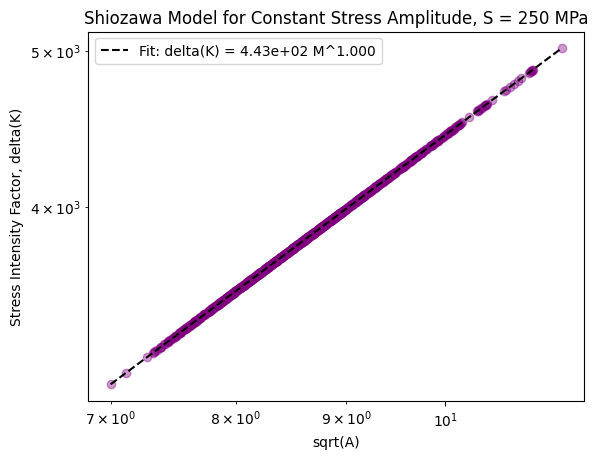

In [ ]:
# log transform
logM = np.log10(M)
logK = np.log10(K)

# linear fit: log_delta_K = b log_sqrt_A + loga
b, loga = np.polyfit(logM, logK, 1)
a = 10**loga

# fitted curve
M_line = np.logspace(np.log10(min(M)), np.log10(max(M)), 200)
K_line = a * M_line**b

# scatter plot of delta(K) vs sqrt(A)
plt.scatter(M, K, alpha=0.4, color='purple')

# plot fit
plt.plot(M_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} M^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Model for Constant Stress Amplitude, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend()

plt.show()

Under constant stress, as the size of the defect increases, the stress intensity factor increases exponentially since both x and y, delta(K) and sqrt(A), respectively, are log-transformed.

#### Confidence Intervals

In [ ]:
logM = np.log10(M)

# create bins for logM
bins = np.linspace(min(logM), max(logM), 20)

# calculate mean and std dev of stress values in each bin
K_avg = []
K_std = []
centers = []

for i in range(len(bins) - 1):
    mask = (logM >= bins[i]) & (logM < bins[i+1])
    Ks_in_bin = np.array(K)[mask]

    if Ks_in_bin.size == 0:
        continue
    
    K_avg.append(np.mean(Ks_in_bin))
    K_std.append(np.std(Ks_in_bin))
    centers.append(0.5 * (bins[i] + bins[i+1]))

K_avg = np.array(K_avg)
K_std = np.array(K_std)
centers = np.array(centers)

# confidence intervals, assume 96% CI
upper_K = K_avg + 1.96 * K_std
lower_K = K_avg - 1.96 * K_std

upper = np.array(upper_K)
lower = np.array(lower_K)

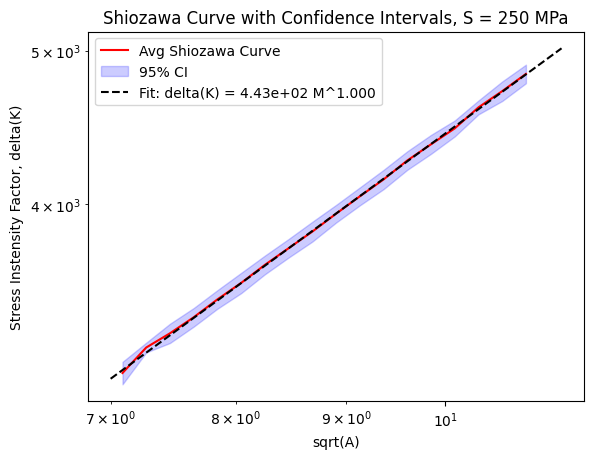

In [ ]:
xvals1 = np.power(10, centers)

plt.plot(xvals1, K_avg, 'red', label='Avg Shiozawa Curve')

plt.fill_between(xvals1, lower_K, upper_K,
                 color='blue',
                 alpha=0.2,
                 label='95% CI')

# plot fit
plt.plot(M_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} M^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Curve with Confidence Intervals, S = 250 MPa')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Instensity Factor, delta(K)')

plt.legend()
plt.show()

The narrow confidence intervals imply a good certainty in the estimate.

### Reliability Curves
the probability a specimen survives beyond a given 

fraction of specimens that survive past N cycles:

**R(N) = P(N_f > N)**

In [ ]:
# sort fatigue lives
lives_sorted = np.sort(np.array(lives))

# calculate survival probability
j = len(lives_sorted)
R = 1 - np.arange(j) / j

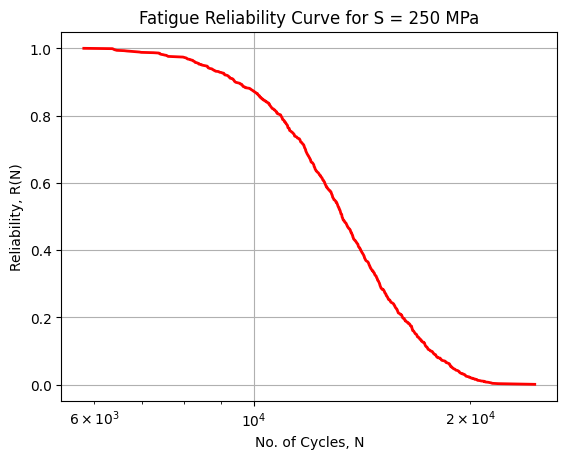

In [ ]:
# plot reliability curve
plt.plot(lives_sorted, R,
         color='red',
         linewidth=2,
         label='Monte Carlo')
plt.xscale("log")

# axis labels
plt.title("Fatigue Reliability Curve for S = 250 MPa")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.grid()
plt.show()

At low cycle counts, near one, almost nothing has failed yet. Then the curve drops: at around 50%, reliability has decreased and about half have failed. Finally, reliability approaches zero, so around 1100 cycles, almost all specimens have failed.

#### Weibull Reliability Model
This is more of a **statistical reliability model** rather than a crack-growth physics model.

Instead of simulating defects directly, failure probability is modeled with a Weibull distribution.

Typically, **R(N) = exp[-(N/η)^β]**

where:

- R(N) = reliability
- η = characteristic life
- β = Weibull shape parameter

This model describes how failure probability evolves with cycles.

In [ ]:
# estimate weibull parameters from generated data
shape, loc, scale = weibull_min.fit(lives, floc=0)

# calculate theoretical reliability based on estimated weibull parameters
N_vals = np.linspace(min(lives), max(lives), 200)
R_theory = np.exp(-(N_vals / scale)**shape)

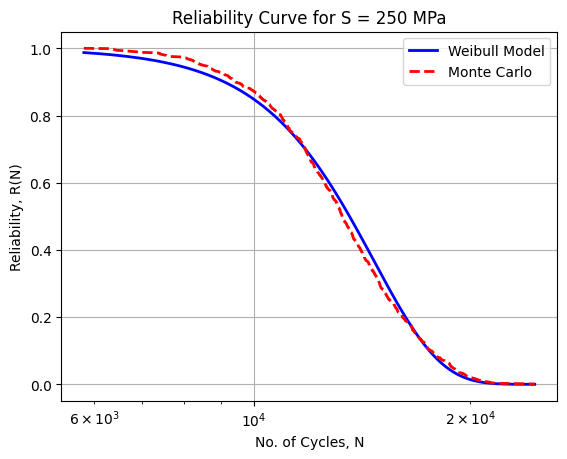

In [ ]:
# plot theoretical reliability curve
plt.plot(N_vals, R_theory,
         color="blue",
         linewidth=2,
         label="Weibull Model")

# plot empirical reliability curve
lives_sorted = np.sort(lives)
R_emp = 1 - np.arange(len(lives)) / len(lives)

plt.plot(lives_sorted, R_emp,
         linestyle="--",
         color="red",
         linewidth=2,
         label="Monte Carlo")

# axis labels
plt.title("Reliability Curve for S = 250 MPa")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Since the Weibull reliability curve and the Monte Carlo reliability curve are mostly close, the probabilistic model is internally consistent and the Weibull approximation is describing the failure behavior pretty well.

### Normalized Life
plot **delta(K_i) vs N/sqrt(A)**
where N/sqrt(A) = defect-normalized life

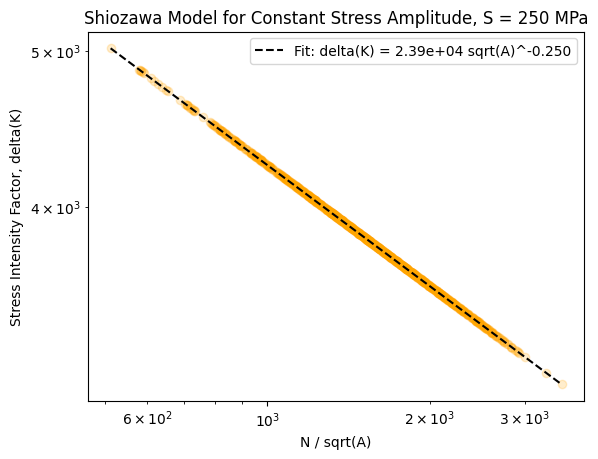

In [ ]:
# log transform
logN_norm = np.log10(N_norm)

# linear fit: log_delta_K = b log_sqrt_A + loga
b, loga = np.polyfit(logN_norm, logK, 1)
a = 10**loga

# fitted curve
N_norm_line = np.logspace(np.log10(min(N_norm)), np.log10(max(N_norm)), 200)
K_line = a * N_norm_line**b

# scatter plot of delta(K) vs N/sqrt(A)
plt.scatter(N_norm, K, alpha=0.2, color='orange')

# plot fit
plt.plot(N_norm_line, K_line, color='black', linestyle='--',
         label=f'Fit: delta(K) = {a:.2e} sqrt(A)^{b:.3f}')

plt.xscale('log')
plt.yscale('log')

# axis labels
plt.title('Shiozawa Model for Constant Stress Amplitude, S = 250 MPa')
plt.xlabel('N / sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend()

plt.show()

## Varying Sress

### Shiozawa Curve
with normalized life plot **delta(K_i) vs N/sqrt(A)** where N/sqrt(A) = defect-normalized life

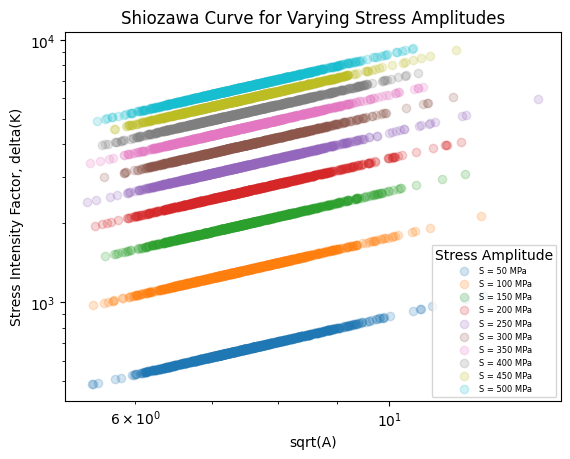

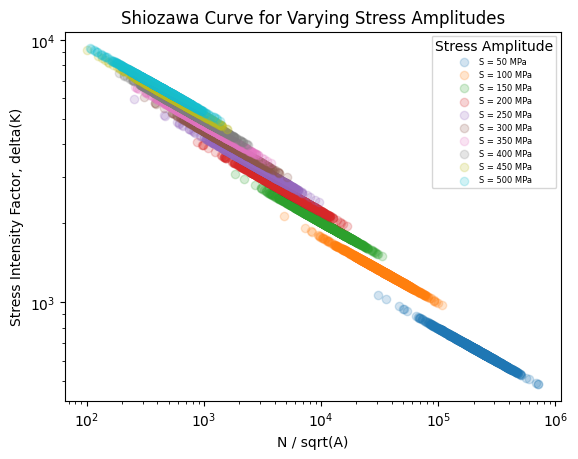

In [ ]:
# vary stress amplitude, S
S_vals = [50, 100, 150, 200, 250, 300, 350, 400, 450, 500]

for S_i in S_vals:

    # temporary lists for this stress amplitude
    M_temp = []
    K_temp = []
    N_norm_temp = []

    lives_temp = []
    max_defects_temp = []

    for i in range(1000):
        # random number of defects for this specimen
        n_local = calculate_Nd(rho_defects, V_gauge_mm3)
        
        # avoid empty specimen
        n_local = max(n_local, 1)

        defects = generate_defects(n_defects, mu, sigma)

        A_crit1 = critical_defect(defects)
        Murakami1 = np.sqrt(A_crit1)
        delta_K1 = stress_intensity_factor(S_i, A_crit1)
        N1 = fatigue_life(S_i, A_crit1, C, m, n)
        N_normal1 = N1 / Murakami1

        # store points for this stress amplitude
        M_temp.append(Murakami1)
        K_temp.append(delta_K1)
        N_norm_temp.append(N_normal1)

        lives_temp.append(N1)
        max_defects_temp.append(np.max(defects))
        
    # plot 1: delta(K) vs sqrt(A), for all points at this stress amplitude
    plt.figure(1)
    plt.scatter(M_temp, K_temp, alpha=0.2, label=f'S = {S_i} MPa')

    # plot 2: delta(K) vs N/sqrt(A) for this stress amplitude
    plt.figure(2)
    plt.scatter(N_norm_temp, K_temp, alpha=0.2, label=f'S = {S_i} MPa')

# figure 1: delta(K) vs sqrt(A)
plt.figure(1)

plt.xscale('log')
plt.yscale('log')

# figure 1: axis labels
plt.title('Shiozawa Curve for Varying Stress Amplitudes')
plt.xlabel('sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend(title='Stress Amplitude', fontsize=6, loc='lower right')

# log scales
plt.xscale('log')
plt.yscale('log')

plt.legend(title='Stress Amplitude', fontsize=6, loc='lower right')

# figure 2: delta(K) vs N/sqrt(A)
plt.figure(2)

plt.xscale('log')
plt.yscale('log')

# figure 2: axis labels
plt.title('Shiozawa Curve for Varying Stress Amplitudes')
plt.xlabel('N / sqrt(A)')
plt.ylabel('Stress Intensity Factor, delta(K)')

plt.legend(title='Stress Amplitude', fontsize=6, loc='upper right')

plt.show()

A higher stress amplitude results in a higher stress intensity factor.
The stress intensity factor and Murakami factor are related exponentially since both axes are log-transformed.

### Reliability Curves
the probability a specimen survives beyond a given life

fraction of specimens that survive past N cycles:

**R(N) = P(N_f > N)**

In [ ]:
# sort fatigue lives
lives_sorted1 = np.sort(np.array(lives_temp))

# calculate survival probability
j1 = len(lives_sorted1)
R1 = 1 - np.arange(j1) / j1

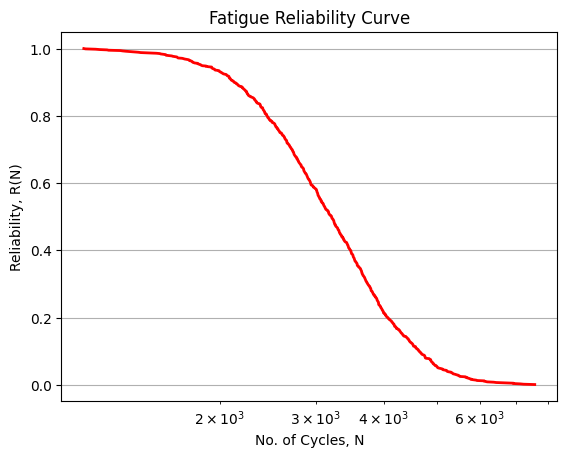

In [ ]:
# plot reliability curve
plt.plot(lives_sorted1, R1,
         color='red',
         linewidth=2,
         label='Monte Carlo')
plt.xscale("log")

# axis labels
plt.title("Fatigue Reliability Curve")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.grid()
plt.show()

At low cycle counts, near 100% reliability, almost nothing has failed yet. At around 60%, reliability has decreased and almost half the specimens have failed. Finally, reliability approaches zero, so around 130 cycles, almost all specimens have failed.

#### Weibull Reliability Model
R(N) = exp[-(N/eta)^beta]

In [ ]:
# estimate weibull parameters from generated data
shape, loc, scale = weibull_min.fit(lives_temp, floc=0)

# calculate theoretical reliability based on estimated weibull parameters
N_vals1 = np.linspace(min(lives_temp), max(lives_temp), 200)
R_theory1 = np.exp(-(N_vals1 / scale)**shape)

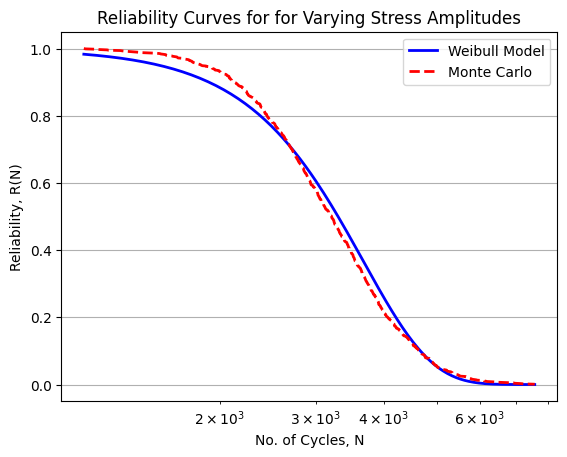

In [ ]:
# plot theoretical reliability curve
plt.plot(N_vals1, R_theory1,
         color="blue",
         linewidth=2,
         label="Weibull Model")

# plot empirical reliability curve
lives_sorted1 = np.sort(lives_temp)
R_emp1 = 1 - np.arange(len(lives_temp)) / len(lives_temp)

plt.plot(lives_sorted1, R_emp1,
         linestyle="--",
         color="red",
         linewidth=2,
         label="Monte Carlo")

# axis labels
plt.title("Reliability Curves for for Varying Stress Amplitudes")
plt.xlabel("No. of Cycles, N")
plt.ylabel("Reliability, R(N)")

plt.xscale("log")
plt.legend()
plt.grid()
plt.show()

Since the Weibull reliability curve and the Monte Carlo reliability curve are mostly close, the probabilistic model is internally consistent and the Weibull approximation is describing the failure behavior pretty well.

# Export Info

In [ ]:
# export markdowns
import json

notebook = "workflow_2.ipynb"
output = "workflow_2_markdown_notes.md"

with open(notebook, "r", encoding="utf-8") as f:
    nb = json.load(f)

markdown_cells = []

for cell in nb["cells"]:
    if cell["cell_type"] == "markdown":
        markdown_cells.append("".join(cell["source"]))

with open(output, "w", encoding="utf-8") as f:
    f.write("\n\n---\n\n".join(markdown_cells))

In [ ]:
# export variables
with pd.ExcelWriter("project_snapshot.xlsx") as writer:

    # constants
    constants_df.to_excel(writer,
                          sheet_name="Constants",
                          index=False)

    # Monte Carlo results
    mc_df.to_excel(writer,
                   sheet_name="MonteCarlo",
                   index=False)

    # Weibull fit
    weibull_df.to_excel(writer,
                        sheet_name="Weibull",
                        index=False)

    # defect population
    defects_df.to_excel(writer,
                        sheet_name="Defects",
                        index=False)

IndexError: At least one sheet must be visible